In [25]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from matplotlib import animation
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

In [26]:
def apply_bc (phi):
    phi = phi.copy()
    phi[0, :]  = 0
    phi[-1, :] = 0
    phi[:, 0]  = 0
    phi[:, -1] = 0
    return phi

def RK4 (h, x0, y0, f, n) :
    x = x0
    eta = y0.copy()

    xs = np.zeros(n+1)
    ys = np.zeros((n+1,) + y0.shape, dtype=complex)

    for i in range(n) :

        eta = apply_bc(eta)
        
        xs[i] = x
        ys[i] = eta

        k_1 = f(x, eta)
        k_2 = f(x + h/2, apply_bc(eta + h * k_1/2))
        k_3 = f(x + h/2, apply_bc(eta + h * k_2/2))
        k_4 = f(x + h, apply_bc(eta + h * k_3))

        eta = eta + h / 6 * (k_1 + 2*k_2 + 2*k_3 + k_4)
        eta = apply_bc(eta)
        x = x + h

    eta = apply_bc(eta)
    xs[n] = x
    ys[n] = eta
    
    return xs, ys


def psi0(x, y, y0, sigma, p):
    x0, y0 = y0
    px, py = p
    return (np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / sigma ** 2)
            * np.exp(1j * (px * x + py * y)))


def H_e(phi, V_tot, a):
    phi_m1_x = np.roll(phi, -1, axis=1)
    phi_p1_x = np.roll(phi, +1, axis=1)
    phi_m1_y = np.roll(phi, -1, axis=0)
    phi_p1_y = np.roll(phi, +1, axis=0)

    k0 = 1 / (2 * a[0] ** 2)
    k1 = 1 / (2 * a[1] ** 2)

    kinetic = (- k0 * (phi_m1_x + phi_p1_x) - k1 * (phi_m1_y + phi_p1_y) + 2 * (k0 + k1) * phi)

    return apply_bc(kinetic + V_tot * phi)

In [27]:
t_in = 0.0
t_fin = 3
delta_tau = 0.0005
n_step = int((t_fin - t_in) / delta_tau)

N = 128
L = 16

delta_x = L / N
delta_y = L / N

a = [delta_x, delta_y]

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)

X, Y = np.meshgrid(x, y)

y0 = [L / 8, L / 2]

sigma_m = 1
p = [(2 * np.pi) * 12 / L, 0.0]


phi0 = psi0(X, Y, y0, sigma_m, p)
norma = np.sum(np.abs(phi0)**2) * delta_x * delta_y
phi0_norm = phi0 / np.sqrt(norma)

print("Norma iniziale =", np.sum(np.abs(phi0_norm)**2)* delta_x * delta_y)

Norma iniziale = 0.9999999999999996


In [28]:
V_static = np.zeros((N, N))

a_barrier = delta_x

x_barrier0 = L / 4
x_barrier1 = L / 4 + a_barrier

mask_muro = ((X >= x_barrier0) & (X <= x_barrier1))

centro_y1 = L / 2 - sigma_m 
centro_y2 = L / 2 + sigma_m 

semi_ampiezza = 1
fenditura_1 = ((Y >= centro_y1 - semi_ampiezza) & (Y <= centro_y1 + semi_ampiezza))
fenditura_2 = ((Y >= centro_y2 - semi_ampiezza) & (Y <= centro_y2 + semi_ampiezza))

V_static[mask_muro] = 500.0
V_static[mask_muro & fenditura_1] = 0.0
V_static[mask_muro & fenditura_2] = 0.0

x_pipe_end = L / 4 + 5
tube_half_width = 1
tube_center_down = centro_y1
tube_center_up = centro_y2

V_wall = 500.0

# tubo superiore:
wall_up_lower = ((X > x_barrier1) & (X <= x_pipe_end) & np.isclose(Y, tube_center_up - tube_half_width, atol=delta_y / 2))
wall_up_upper = ((X > x_barrier1) & (X <= x_pipe_end) & np.isclose(Y, tube_center_up + tube_half_width, atol=delta_y / 2))

# tubo inferiore
wall_down_lower = ((X > x_barrier1) & (X <= x_pipe_end) & np.isclose(Y, tube_center_down - tube_half_width, atol=delta_y / 2))
wall_down_upper = ((X > x_barrier1) & (X <= x_pipe_end) & np.isclose(Y, tube_center_down + tube_half_width, atol=delta_y / 2))

# muro centrale tra i tubi
mask_central_wall = ((X > x_barrier1) & (X <= x_pipe_end) & (Y >= tube_center_down + tube_half_width) & (Y <= tube_center_up - tube_half_width))

# aggiungo le pareti
V_static[wall_up_lower] = V_wall
V_static[wall_up_upper] = V_wall
V_static[wall_down_lower] = V_wall
V_static[wall_down_upper] = V_wall
V_static[mask_central_wall] = V_wall

mask_up = ((X > x_barrier1) & (X <= x_pipe_end) & (Y >= tube_center_up - tube_half_width) & (Y <= tube_center_up + tube_half_width))
mask_down = ((X > x_barrier1) & (X <= x_pipe_end) & (Y >= tube_center_down - tube_half_width) & (Y <= tube_center_down + tube_half_width))

# tolgo dalle maschere le pareti, così il potenziale elettrico viene applicato solo alla regione interna dei tubi.
mask_up = mask_up & ~(wall_up_lower | wall_up_upper)
mask_down = mask_down & ~(wall_down_lower | wall_down_upper)


In [29]:
x_screen_coord = x_pipe_end + 5
x_screen = int(round(x_screen_coord/delta_x))

v_group = np.sin(p[0]* delta_x)/delta_x

t_on = (x_barrier1 + 0.8 - y0[0]) / v_group
t_off = (x_pipe_end - 0.8 - y0[0]) / v_group
delta_t_pulse = t_off - t_on

print("t_on", t_on)
print("t_off", t_off)

def Ve_field(t, V1, V2):
    if t_on <= t <= t_off:
        return V1 * mask_up + V2 * mask_down

    return np.zeros_like(X)


def make_H_wrapped(V1, V2):

    def H_wrapped(t, phi):

        Ve = Ve_field(t, V1, V2)

        V_tot = V_static + Ve

        return -1j * H_e(apply_bc(phi), V_tot, a)

    return H_wrapped

t_on 0.658107613168504
t_off 1.3949631458614442


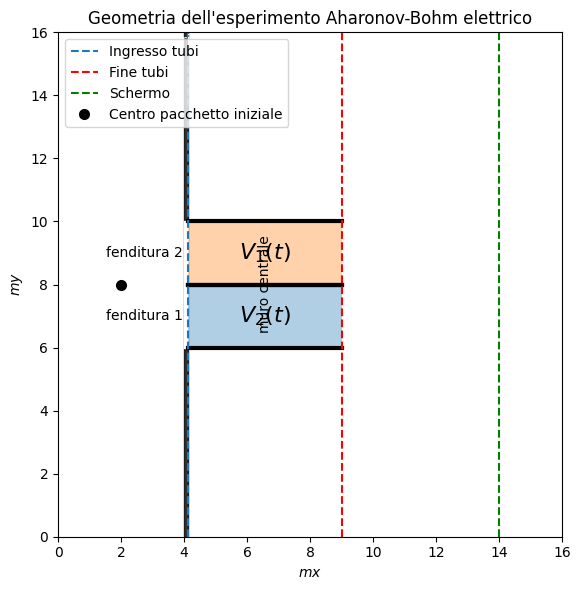

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlim(0, L)
ax.set_ylim(0, L)

ax.fill_between([x_barrier0, x_barrier1], 0, L, color="black", alpha=0.8)

ax.fill_between([x_barrier0, x_barrier1], centro_y1 - semi_ampiezza, centro_y1 + semi_ampiezza, color="white")
ax.fill_between([x_barrier0, x_barrier1], centro_y2 - semi_ampiezza, centro_y2 + semi_ampiezza, color="white")

ax.fill_between([x_barrier1, x_pipe_end], tube_center_down - tube_half_width, tube_center_down + tube_half_width, alpha=0.35)
ax.fill_between([x_barrier1, x_pipe_end], tube_center_up - tube_half_width, tube_center_up + tube_half_width, alpha=0.35)

for yy in [tube_center_down - tube_half_width, tube_center_down + tube_half_width, tube_center_up - tube_half_width, tube_center_up + tube_half_width]:
    ax.plot([x_barrier1, x_pipe_end], [yy, yy], color="black", linewidth=3)

ax.fill_between([x_barrier1, x_pipe_end], tube_center_down + tube_half_width, tube_center_up - tube_half_width, color="gray", alpha=0.8)

ax.axvline(x_barrier1, linestyle="--", linewidth=1.5, label="Ingresso tubi")
ax.axvline(x_pipe_end, linestyle="--", linewidth=1.5, label="Fine tubi", color = "red")
ax.axvline(x_screen_coord, linestyle="--", linewidth=1.5, label="Schermo", color = "green")

ax.plot(y0[0], y0[1], "ko", markersize=7, label="Centro pacchetto iniziale")

ax.text((x_barrier1 + x_pipe_end) / 2, tube_center_up, r"$V_1(t)$", ha="center", va="center", fontsize=16)
ax.text((x_barrier1 + x_pipe_end) / 2, tube_center_down, r"$V_2(t)$", ha="center", va="center", fontsize=16)
ax.text((x_barrier0 + x_barrier1) / 2, L - 0.4, "barriera", color="white", ha="center")
ax.text(x_barrier0 - 0.05, centro_y1, "fenditura 1", ha="right", va="center")
ax.text(x_barrier0 - 0.05, centro_y2, "fenditura 2", ha="right", va="center")
ax.text((x_barrier1 + x_pipe_end) / 2, L / 2, "muro centrale", rotation=90, ha="center", va="center")

ax.set_xlabel(r"$mx$")
ax.set_ylabel(r"$my$")
ax.set_title("Geometria dell'esperimento Aharonov-Bohm elettrico")
ax.set_aspect("equal")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("AB_elettrico_geometria.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
Phi_e = 0.5
V1 = np.pi * Phi_e / delta_t_pulse
V2 = -np.pi * Phi_e / delta_t_pulse
delta_phi = -(V1 - V2) * delta_t_pulse

H_wrapped = make_H_wrapped(V1, V2)
t_values, psi_values = RK4(delta_tau, t_in, phi0_norm, H_wrapped, n_step)
psi_square = np.abs(psi_values) ** 2

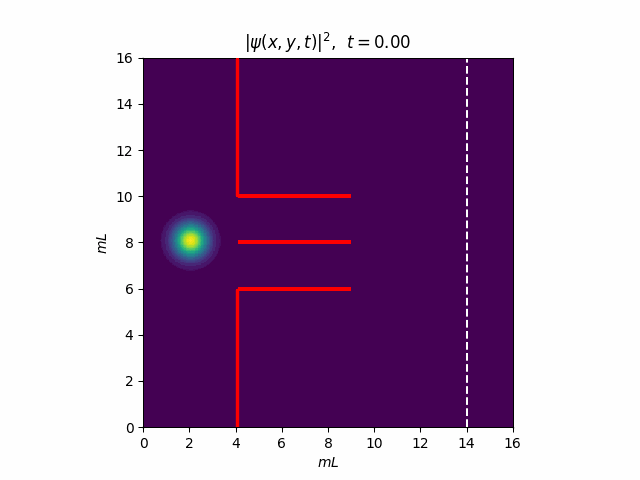

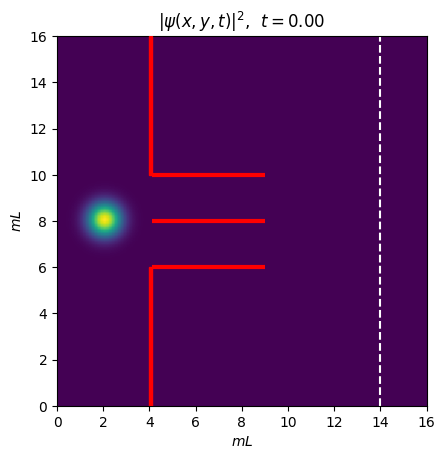

In [ ]:
fig, ax = plt.subplots()
psi_square_plot = ax.imshow(psi_square[0].reshape(N, N), origin='lower', extent=[0, L, 0, L])
title = ax.set_title(r'$|\psi(x,y,t)|^{2}$,  $t=0.00$')
ax.set_xlabel(r'$mL$')
ax.set_ylabel(r'$mL$')

y_low = centro_y1 - semi_ampiezza
y_high = centro_y2 + semi_ampiezza
w = x_barrier1 - x_barrier0
for y_start, h in ((0, y_low), (y_high, L - y_high)):
    ax.add_patch(Rectangle((x_barrier0, y_start), w, h,
                           facecolor='red', edgecolor='red', lw=1, zorder=3))

y_walls = [tube_center_down - tube_half_width,
           0.5 * (tube_center_down + tube_center_up),
           tube_center_up + tube_half_width]
ax.hlines(y_walls, x_barrier1, x_pipe_end, color='red', lw=3, zorder=4)

# riempimento azzurro dei tubi, visibile solo con V acceso
tube_fills = []
for yc in (tube_center_down, tube_center_up):
    fill = Rectangle((x_barrier1, yc - tube_half_width),
                     x_pipe_end - x_barrier1, 2 * tube_half_width,
                     facecolor='cyan', edgecolor='none', alpha=0.0, zorder=3)
    ax.add_patch(fill)
    tube_fills.append(fill)

ax.axvline(x_screen * delta_x, color='white', ls='--', lw=1.5)

def animate(i):
    psi_square_plot.set_data(psi_square[i].reshape(N, N))
    psi_square_plot.set_clim(vmin=np.min(psi_square[i]), vmax=np.max(psi_square[i]))
    t = t_values[i]
    on = t_on <= t <= t_off
    for f in tube_fills:
        f.set_alpha(0.35 if on else 0.0)
    title.set_text(rf'$|\psi(x,y,t)|^{{2}}$,  $t={t:.2f}$')
    return [psi_square_plot, title, *tube_fills]

step = 20
frames = range(0, len(psi_square), step)
ani = animation.FuncAnimation(fig, animate, frames=frames, blit=False)
writer = animation.PillowWriter(fps=10, bitrate=1800)
ani.save('Double_slit_ABeffect_electric.gif', writer=writer)

Image('Double_slit_ABeffect_electric.gif')

t = 0.00   norma = 9.999665418516e-01
t = 1.00   norma = 9.999665577829e-01
t = 1.50   norma = 9.999665777473e-01
t = 2.50   norma = 9.999665697768e-01


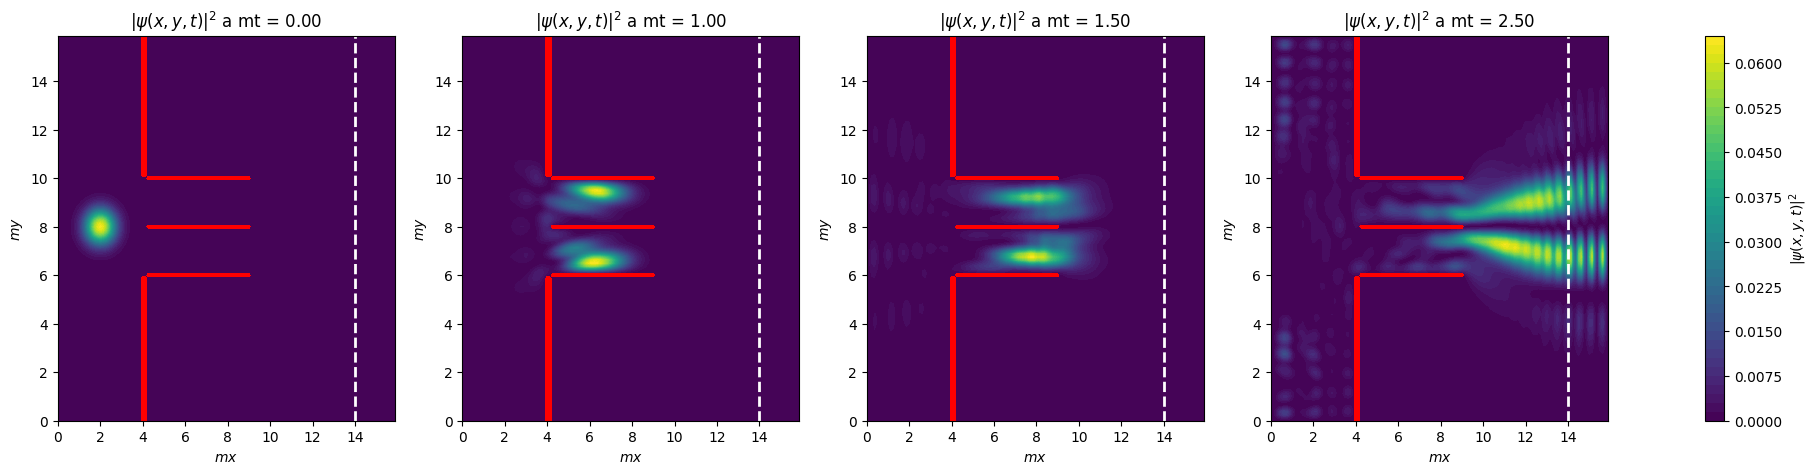

probabilità sui bordi = 0.0


In [33]:
norme = np.sum(np.abs(psi_values)**2, axis=(1,2)) * delta_x * delta_y

times_to_plot = [0, 1, 1.5, 2.5]

for t_target in times_to_plot:
    idx = np.argmin(np.abs(t_values - t_target))
    print(f"t = {t_values[idx]:.2f}   " 
          f"norma = {norme[idx]:.12e}")


fig, axes = plt.subplots(1, len(times_to_plot), figsize=(25,5))

for ax, t_target in zip(axes, times_to_plot):

    idx = np.argmin(np.abs(t_values - t_target))
    frame = psi_square[idx].reshape(N, N)

    contour = ax.contourf(X, Y, frame, levels=50, cmap='viridis')
    ax.contourf(X, Y, V_static, levels=[V_static.max()/2, V_static.max()*2], colors='red')

    ax.axvline(x_screen_coord, color='white', linestyle='--', linewidth=2)

    ax.set_title(fr"$|\psi(x,y,t)|^2$ a mt = {t_values[idx]:.2f}")
    ax.set_xlabel('$mx$')
    ax.set_ylabel('$my$')

plt.colorbar(contour, ax=axes.ravel().tolist(), label=r'$|\psi(x,y,t)|^2$')
plt.show()

border_probability = (
    np.sum(np.abs(psi_values[:, 0, :])**2) +
    np.sum(np.abs(psi_values[:, -1, :])**2) +
    np.sum(np.abs(psi_values[:, :, 0])**2) +
    np.sum(np.abs(psi_values[:, :, -1])**2)
)

print("probabilità sui bordi =", border_probability)

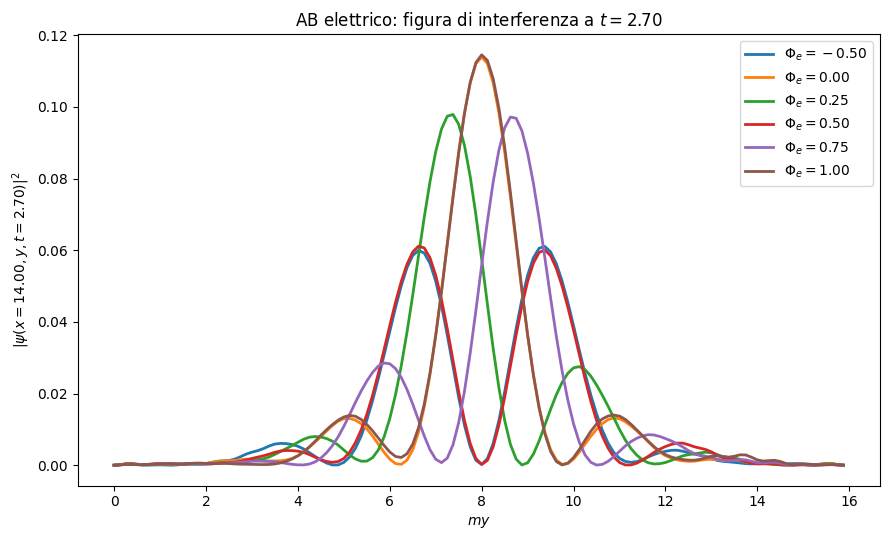

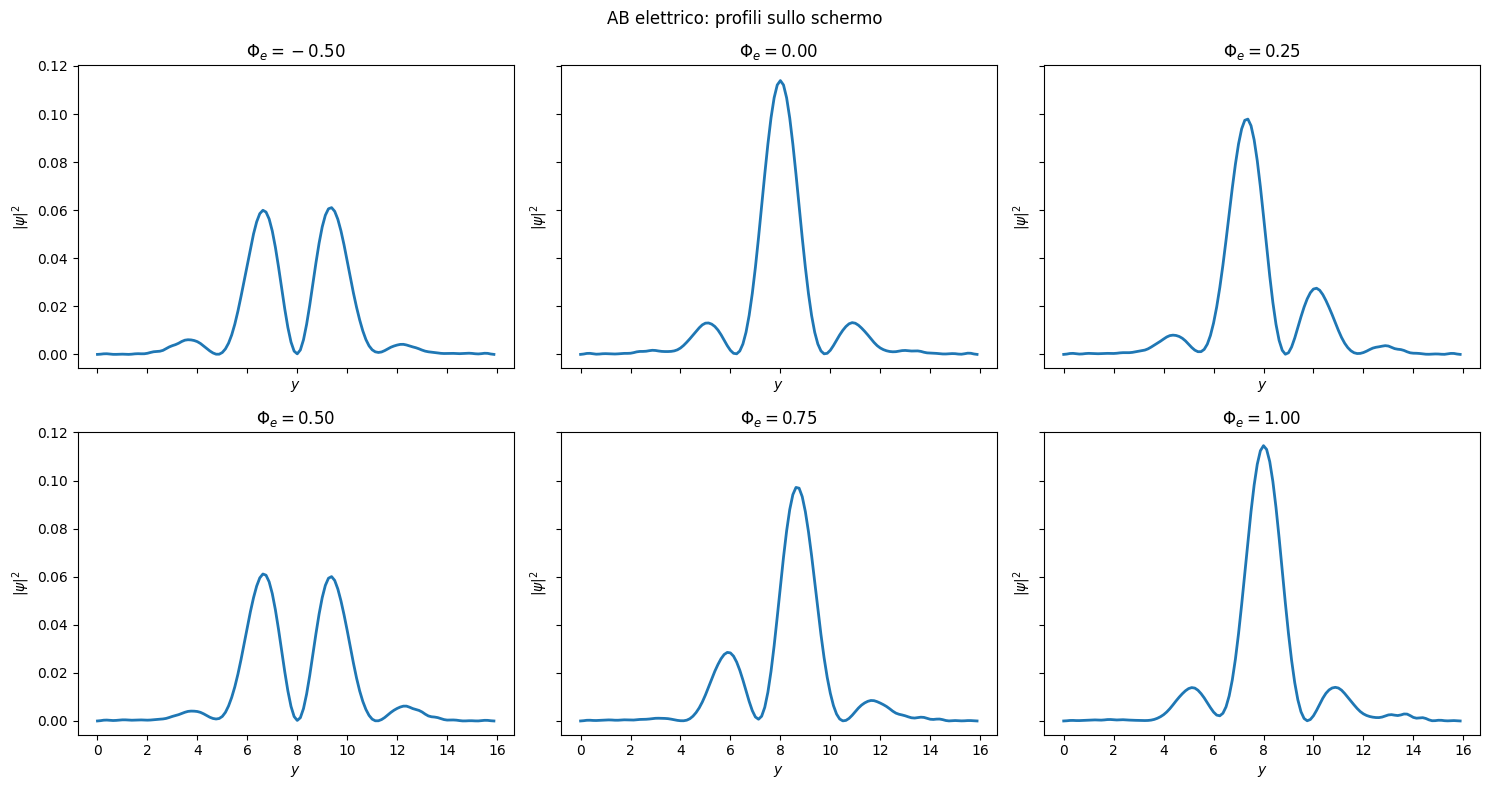

In [ ]:
phi_e_values = [-0.5, 0.0, 0.25, 0.5, 0.75, 1.0]
t_measure = (x_screen_coord - y0[0]) / v_group

schermo = {}

for Phi_e in phi_e_values:

    V1 = np.pi * Phi_e / delta_t_pulse
    V2 = -np.pi * Phi_e / delta_t_pulse

    H_wrapped = make_H_wrapped(V1, V2)

    t_values, psi_values = RK4(delta_tau, t_in, phi0_norm, H_wrapped, n_step)
    psi_square = np.abs(psi_values) ** 2

    idx_t = np.argmin(np.abs(t_values - t_measure))
    schermo[Phi_e] = psi_square[idx_t, :, x_screen]


fig, ax = plt.subplots(figsize=(9, 5.5))

for Phi_e in phi_e_values:
    ax.plot(y,schermo[Phi_e], linewidth=2, label=fr"$\Phi_e={Phi_e:.2f}$")
    
ax.set_xlabel(r"$my$")
ax.set_ylabel(fr"$|\psi(x={x_screen_coord:.2f}, y, t={t_measure:.2f})|^2$")
ax.set_title(fr"AB elettrico: figura di interferenza "fr"a $t={t_measure:.2f}$")
ax.legend()
plt.tight_layout()
plt.savefig("AB_elettrico_interferenza.png", dpi=300, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for ax, Phi_e in zip(axes.ravel(), phi_e_values):
    ax.plot(y, schermo[Phi_e], linewidth=2)
    ax.set_title(fr"$\Phi_e={Phi_e:.2f}$")
    ax.set_xlabel(r"$y$")
    ax.set_ylabel(r"$|\psi|^2$")

fig.suptitle("AB elettrico: profili sullo schermo")
plt.tight_layout()
plt.savefig("AB_elettrico_pannelli.png", dpi=300, bbox_inches="tight")
plt.show()

Interfrangia misurata (dai picchi) = 2.8750

Phi_e = -0.500
y_picco misurato = 6.6250  (y0 = 8.0000)
shift misurato  = +1.3750
shift teorico (da Lambda misurata) = +1.4375

Phi_e = 0.250
y_picco misurato = 7.3750  (y0 = 8.0000)
shift misurato  = +0.6250
shift teorico (da Lambda misurata) = +0.7188

Phi_e = 0.500
y_picco misurato = 6.6250  (y0 = 8.0000)
shift misurato  = +1.3750
shift teorico (da Lambda misurata) = +1.4375

Phi_e = 0.750
y_picco misurato = 8.6250  (y0 = 8.0000)
shift misurato  = +0.6250
shift teorico (da Lambda misurata) = +0.7188

Phi_e = 1.000
y_picco misurato = 8.0000  (y0 = 8.0000)
shift misurato  = +0.0000
shift teorico (da Lambda misurata) = +0.0000


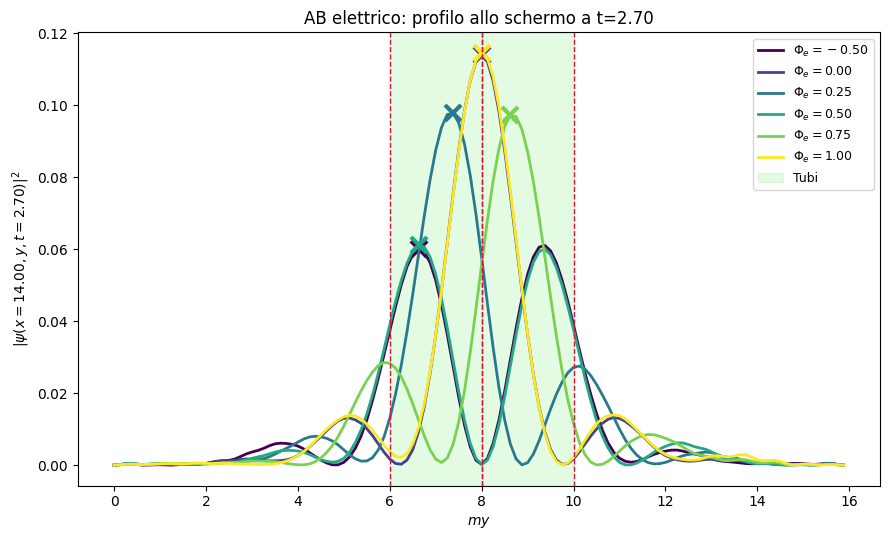

In [ ]:
from scipy.signal import find_peaks

phi_da_plottare = phi_e_values 
density_y_dict = schermo

bordo_inf_f1, bordo_sup_f1 = centro_y1 - semi_ampiezza, centro_y1 + semi_ampiezza
bordo_inf_f2, bordo_sup_f2 = centro_y2 - semi_ampiezza, centro_y2 + semi_ampiezza

#riferimento a phi_e=0
idx0, _ = find_peaks(density_y_dict[0.0], prominence=0.05*density_y_dict[0.0].max())
y0_peaks = y[idx0]
I0_peaks = density_y_dict[0.0][idx0]
y0_top = y0_peaks[np.argmax(I0_peaks)]

passo_frangia = np.mean(np.diff(y0_peaks))
print(f"Interfrangia misurata (dai picchi) = {passo_frangia:.4f}")

picchi_trovati = {0.0: y0_top}

for Phi in [p for p in phi_da_plottare if p != 0.0]:
    I = density_y_dict[Phi]
    idx, _ = find_peaks(I, prominence=0.05*I.max())
    yi_peaks = y[idx]
    y_top = yi_peaks[np.argmin(np.abs(yi_peaks - y0_top))]
    picchi_trovati[Phi] = y_top

    shift_misurato = abs(y_top - y0_top)

    shift_teorico_da_misura = abs(Phi * passo_frangia)
    shift_teorico_da_misura_wrapped = min(shift_teorico_da_misura % passo_frangia, passo_frangia - shift_teorico_da_misura % passo_frangia)

    print("")
    print(f"Phi_e = {Phi:.3f}")
    print(f"y_picco misurato = {y_top:.4f}  (y0 = {y0_top:.4f})")
    print(f"shift misurato  = {shift_misurato:+.4f}")
    print(f"shift teorico (da Lambda misurata) = {shift_teorico_da_misura_wrapped:+.4f}")


fig, ax = plt.subplots(figsize=(9, 5.5))
colori = plt.cm.viridis(np.linspace(0, 1, len(phi_da_plottare)))
for Phi, col in zip(phi_da_plottare, colori):
    I = density_y_dict[Phi]
    ax.plot(y, I, color=col, lw=2, label=fr'$\Phi_e={Phi:.2f}$')
    y_top = picchi_trovati[Phi]
    ax.plot(y_top, I[np.argmin(np.abs(y - y_top))], 'x', color=col, ms=12, mew=3)

ax.axvspan(bordo_inf_f1, bordo_sup_f1, color='lightgreen', alpha=0.25, label='Tubi')
ax.axvspan(bordo_inf_f2, bordo_sup_f2, color='lightgreen', alpha=0.25)
for edge in [bordo_inf_f1, bordo_sup_f1, bordo_inf_f2, bordo_sup_f2]:
    ax.axvline(edge, color='crimson', linestyle='--', lw=1)

ax.set_xlabel("$my$")
ax.set_ylabel(fr"$|\psi(x={x_screen_coord:.2f}, y, t={t_measure:.2f})|^2$")
ax.set_title(f"AB elettrico: profilo allo schermo a t={t_measure:.2f}")
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("AB_elettrico_shift_profili.png", dpi=300, bbox_inches="tight")
plt.show()